---
# Waterfowl CNN Model - Exploratory Notebook
---

## Introduction

This notebook contains a Convolutional Neural Network (CNN) built from scratch using TensorFlow/Keras, optimized via Bayesian Optimization (Keras Tuner), and regularized to prevent overfitting on small-scale ecological data. In particular, it identifies species of waterfowl from image data (ducks, geese, swans). 

This is an exploratory notebook, the aim of which is to detail the model development and decision process.

In [ ]:
import zipfile
import os 
import shutil

# Path to the zip file
zip_file_path = 'lake_bird_images.zip'

# Remove existing directory if it exists to avoid extraction issues
if os.path.exists('lake_bird_images'):
    shutil.rmtree('lake_bird_images')

# Unzipping the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('.')

# Specific paths for training and testing folders
train_path = os.path.join('lake_bird_images', 'train')
test_path = os.path.join('lake_bird_images', 'test')

In [3]:
# Library Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd

# Random number management
import random

# File management
import json 
import os 
import glob

# TensorFlow Keras modules
from tensorflow.keras import datasets
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import utils
from tensorflow.keras import callbacks
from tensorflow.keras import regularizers
from tensorflow.keras import optimizers
from tensorflow.keras import Input
from tensorflow.keras import mixed_precision
from tensorflow.keras.models import load_model

# Scikit-learn utility functions
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

# Keras Tuner for hyperparameter tuning
import keras_tuner as kt
# Note: if you don't have keras-tuner installed, you can install it via pip:
# !pip install keras-tuner

# Seaborn for better plotting
import seaborn as sns
# Note: if you don't have seaborn installed, you can install it via pip:
# !pip install seaborn

2026-02-02 13:55:29.050125: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 13:55:29.249763: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-02 13:55:30.599384: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
# # Set seed for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Force deterministic operations on GPU (reproducible)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

# Enable mixed precision on GPU for speedup
mixed_precision.set_global_policy('mixed_float16')


In [5]:
# Store image size and batch size
image_height = 320
image_width = 320
batch_size = 32
num_classes = 3

We have a small dataset for image classification (~1800), so we use a small validation split (15%) to preserve as much training data as possible

In [6]:
# Load training data and split into training and validation sets
print('---Training and Validation Sets---')
train_dataset, valid_dataset = utils.image_dataset_from_directory(
    train_path,
    labels = 'inferred',
    label_mode = 'categorical',
    color_mode = 'rgb',
    image_size = (image_height, image_width),
    batch_size = batch_size,
    shuffle = True,
    validation_split = 0.15,
    subset = 'both',
    seed = SEED
)

# Load test data
print('---Testing Set---')
test_dataset = utils.image_dataset_from_directory(
    test_path,
    labels = 'inferred',
    label_mode = 'categorical',
    color_mode = 'rgb',
    image_size = (image_height, image_width),
    batch_size = batch_size,
    shuffle = False,
    seed = SEED
)

class_names = train_dataset.class_names

---Training and Validation Sets---
Found 1814 files belonging to 3 classes.
Using 1542 files for training.
Using 272 files for validation.


I0000 00:00:1770040532.499287 1937970 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6052 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


---Testing Set---
Found 783 files belonging to 3 classes.


Let us check that our data is loaded correctly:

In [7]:
# Check class names are correct
print('Testing:')
print(train_dataset.class_names)
print('Validation:')
print(valid_dataset.class_names)
print('Training:')
print(test_dataset.class_names)

Testing:
['duck', 'goose', 'swan']
Validation:
['duck', 'goose', 'swan']
Training:
['duck', 'goose', 'swan']


2026-02-02 13:55:33.820251: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


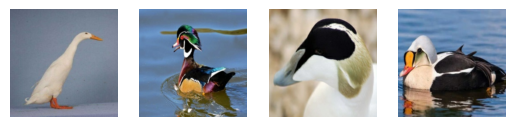

In [8]:
# View some ducks
ducks = 0
fig, axs = plt.subplots(1, 4)

i = 0
for batch_x, batch_y in train_dataset.as_numpy_iterator():
    for x, y in zip(batch_x, batch_y):
        if i >= 4:
            break
        if y[ducks] == 1:
            axs[i].imshow(x.astype(int))
            axs[i].set_axis_off()
            i += 1

2026-02-02 13:55:34.128158: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


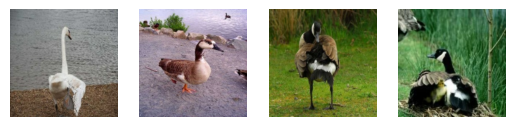

In [9]:
# View some geese
geese = 1
fig, axs = plt.subplots(1, 4)

i = 0
for batch_x, batch_y in train_dataset.as_numpy_iterator():
    for x, y in zip(batch_x, batch_y):
        if i >= 4:
            break
        if y[geese] == 1:
            axs[i].imshow(x.astype(int))
            axs[i].set_axis_off()
            i += 1

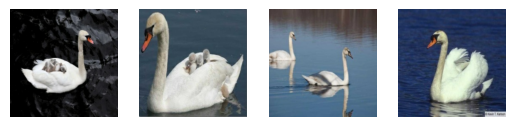

In [10]:
# View some swans
swans = 2
fig, axs = plt.subplots(1, 4)

i = 0
for batch_x, batch_y in train_dataset.as_numpy_iterator():
    for x, y in zip(batch_x, batch_y):
        if i >= 4:
            break
        if y[swans] == 1:
            axs[i].imshow(x.astype(int))
            axs[i].set_axis_off()
            i += 1

Let us consider the baseline accuracy of the model

Random Guess Baseline: What is the probability of being correct with a random guess?

 1/3 = 33.3% chance of being correct

Zero-Rule Baseline: How accurate would the model be if it predicted Goose for everything? We have 981 out of 1814 images are of geese. 

Zero-Rule Accuracy = 981/1814 = 54.1% 

For the model to be useful, accuracy must be above 54.1%, otherwise we are better off just predicting Goose. 

### Model Exploration

What are the main factors affecting recognition of each bird type? 

Low level features (edges and textures): The most distinct markers are geometric, such as the curvature of a swan's neck or triangular profile of a bill. To capture these details, we need to prioritise convolutional blocks with 32 and 64 filters.

High level features: Distinguishing a juvenile duck from a goose requires analysing complex features (plumage patterns) and relative proportions. Deeper blocks with 128 and 256 filters should be included to aggregate these lower-level shapes into semantic concepts (e.g. webbed foot, patterned wing).



Firstly, we need to consider that the dataset is heavily inbalanced in terms of geese, we apply calculated class weights to ensure fair treatment. 

In [11]:
# Extract integer labels from training dataset
y_train = np.concatenate([y for _, y in train_dataset], axis=0)
y_train = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.1898148148148149), 1: np.float64(0.6215235792019347), 2: np.float64(1.8162544169611308)}


2026-02-02 13:55:34.709320: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [12]:
# Optimise data to send to the GPU
AUTOTUNE = tf.data.AUTOTUNE

# Training
train_dataset = train_dataset.cache()
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

# Validation
valid_dataset = valid_dataset.cache()
valid_dataset = valid_dataset.prefetch(buffer_size=AUTOTUNE)

# Testing
test_dataset = test_dataset.cache()
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)


In [13]:
# Global plotting settings
sns.set_theme(
    context="paper",      
    style="whitegrid",
    palette="mako",       
    font_scale=1.2,       
    rc={
        "figure.figsize": (10, 6), 
        "axes.titlesize": 14,       
        "axes.titleweight": "bold", 
        "lines.linewidth": 2.5,     
    }
)

In [14]:
# Define reusable function to print classification report
def print_classification_report(model, dataset, class_names, title):
    print(f'\n{title}')
    
    # Predict
    y_pred_probs = model.predict(dataset)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # True labels
    y_true = np.concatenate([y for _, y in dataset], axis=0)
    if y_true.ndim > 1:
        y_true = np.argmax(y_true, axis=1)
    
    # Report
    print(classification_report(y_true, y_pred, target_names=class_names))


In [15]:
# Define callbacks used for training models

# Stop training if validation loss doesn't improve for x epochs
early_stopping = callbacks.EarlyStopping(
    monitor = 'val_macro_f1',
    mode = 'max',
    patience = 25,
    restore_best_weights = True
)

# Learning rate reducer
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=7, 
    min_lr=1e-6,
    verbose=1
)

Let us firstly try a simple 3-layer CNN just to get a measure of performance. We can add more convolutional blocks, dense layers, augmentations, etc as we explore. 

In [16]:
def build_model_0():
    # Simple 3-layer CNN without augmentations or BatchNorm
    inputs = Input(shape=(image_height, image_width, 3))
    x = layers.Rescaling(1./255)(inputs)

    # Convolutional blocks
    x = layers.Conv2D(32, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(3, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.F1Score(average='macro', name='macro_f1'),
                 tf.keras.metrics.CategoricalAccuracy(name='accuracy')
        ]
    )
    return model

model_1 = build_model_0()
model_1.summary()

model_folder = 'models'
model_path = os.path.join(model_folder, 'model_0.keras')
history_path = os.path.join(model_folder, 'history_model_0.json')
# Create folder if it doesn't exist
os.makedirs(model_folder, exist_ok=True)

# Saves the model every time the validation accuracy improves
checkpoint = callbacks.ModelCheckpoint(
    model_path, 
    monitor='val_macro_f1',
    mode = 'max',
    save_best_only=True,
    verbose=1
)

if os.path.exists(model_path) and os.path.exists(history_path):
    # Load the model from file
    print(f'Found existing model and history. Loading...')
    model = load_model(model_path, compile=True)
    with open(history_path, 'r') as f:
        history = json.load(f)
else: 
    # Train the model and save file
    print('No existing model/history. Training...')
    history_obj = model_1.fit(
        train_dataset,
        validation_data = valid_dataset,
        epochs = 250, 
        callbacks = [early_stopping, reduce_lr, checkpoint],
        class_weight = class_weights
    )
    history = history_obj.history
    # Save as JSON
    with open(history_path, 'w') as f:
        json.dump(history, f)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 318, 318, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 159, 159, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 157, 157, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 78, 78, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 76, 76, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 38, 38, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 184832)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    11,829,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,922,755 (45.48 MB)

 Trainable params: 11,922,755 (45.48 MB)

 Non-trainable params: 0 (0.00 B)

Found existing model and history. Loading...


In [17]:
print_classification_report(model_1, valid_dataset, class_names,
                            'Validation Set Classification Report')


Validation Set Classification Report


2026-02-02 13:55:35.763227: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-02-02 13:55:35.808791: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91800


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
              precision    recall  f1-score   support

        duck       0.25      1.00      0.39        66
       goose       1.00      0.02      0.04       154
        swan       0.00      0.00      0.00        52

    accuracy                           0.25       272
   macro avg       0.42      0.34      0.14       272
weighted avg       0.63      0.25      0.12       272



/home/scott/university/year-4/machine-learning/.venv/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/scott/university/year-4/machine-learning/.venv/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/scott/university/year-4/machine-learning/.venv/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

This model completely fails. Let us add a 256 convolutional block and increase the filter size to 128 on the dense layer.

In [18]:
def build_model_1():
    # 4-layer CNN without augmentations or BatchNorm
    inputs = Input(shape=(image_height, image_width, 3))
    x = layers.Rescaling(1./255)(inputs)

    # Convolutional blocks
    x = layers.Conv2D(32, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # New 256 layer
    x = layers.Conv2D(256, (3,3), activation='relu')(x)
    x = layers.MaxPooling2D(2,2)(x)

    # Dense layers
    x = layers.Flatten()(x)
    # Increase from 64 -> 128
    x = layers.Dense(128, activation='relu')(x)

    outputs = layers.Dense(3, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.F1Score(average='macro', name='macro_f1'),
                 tf.keras.metrics.CategoricalAccuracy(name='accuracy')
        ]
    )
    return model

model_1 = build_model_1()
model_1.summary()

model_folder = 'models'
model_path = os.path.join(model_folder, 'model_1.keras')
history_path = os.path.join(model_folder, 'history_model_1.json')
# Create folder if it doesn't exist
os.makedirs(model_folder, exist_ok=True)

# Saves the model every time the validation accuracy improves
checkpoint = callbacks.ModelCheckpoint(
    model_path, 
    monitor='val_macro_f1',
    mode = 'max',
    save_best_only=True,
    verbose=1
)

if os.path.exists(model_path) and os.path.exists(history_path):
    # Load the model from file
    print(f'Found existing model and history. Loading...')
    model = load_model(model_path, compile=True)
    with open(history_path, 'r') as f:
        history = json.load(f)
else: 
    # Train the model and save file
    print('No existing model/history. Training...')
    history_obj = model_1.fit(
        train_dataset,
        validation_data = valid_dataset,
        epochs = 250, 
        callbacks = [early_stopping, reduce_lr, checkpoint],
        class_weight = class_weights
    )
    history = history_obj.history
    # Save as JSON
    with open(history_path, 'w') as f:
        json.dump(history, f)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 318, 318, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 159, 159, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 157, 157, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 78, 78, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 76, 76, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 38, 38, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 36, 36, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    10,616,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,005,763 (41.98 MB)

 Trainable params: 11,005,763 (41.98 MB)

 Non-trainable params: 0 (0.00 B)

Found existing model and history. Loading...


In [19]:
print_classification_report(model, valid_dataset, class_names,
                            'Validation Set Classification Report')


Validation Set Classification Report
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
              precision    recall  f1-score   support

        duck       0.45      0.45      0.45        66
       goose       0.68      0.60      0.64       154
        swan       0.48      0.63      0.55        52

    accuracy                           0.57       272
   macro avg       0.54      0.56      0.55       272
weighted avg       0.59      0.57      0.58       272



Our model is now able to distinguish between all three classes, although performance is poor.

In [20]:
def build_model_2():
    # 4-layer CNN with BatchNorm
    inputs = Input(shape=(image_height, image_width, 3))
    x = layers.Rescaling(1./255)(inputs)

    # Convolutional blocks
    x = layers.Conv2D(32, (3,3), use_bias=False)(x) # BatchNorm has its own bias
    # BatchNorm -> Activation -> Pooling
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(256, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    outputs = layers.Dense(3, activation='softmax', dtype='float32')(x)

    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.F1Score(average='macro', name='macro_f1'),
                 tf.keras.metrics.CategoricalAccuracy(name='accuracy')
        ]    
    )
    return model

model = build_model_2()
model.summary()

model_folder = 'models'
model_path = os.path.join(model_folder, 'model_2.keras')
history_path = os.path.join(model_folder, 'history_model_2.json')
# Create folder if it doesn't exist
os.makedirs(model_folder, exist_ok=True)

# Saves the model every time the validation accuracy improves
checkpoint = callbacks.ModelCheckpoint(
    model_path, 
    monitor='val_macro_f1',
    mode = 'max',
    save_best_only=True,
    verbose=1
)

if os.path.exists(model_path) and os.path.exists(history_path):
    # Load the model from file
    print(f'Found existing model and history. Loading...')
    model = load_model(model_path, compile=True)
    with open(history_path, 'r') as f:
        history = json.load(f)
else: 
    # Train the model and save file
    print('No existing model/history. Training...')
    history_obj = model.fit(
        train_dataset,
        validation_data = valid_dataset,
        epochs = 250, 
        callbacks = [early_stopping, reduce_lr, checkpoint],
        class_weight = class_weights
    )
    history = history_obj.history
    # Save as JSON
    with open(history_path, 'w') as f:
        json.dump(history, f)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 318, 318, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 318, 318, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 318, 318, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 159, 159, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 157, 157, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 157, 157, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 157, 157, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 78, 78, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 76, 76, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 76, 76, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 76, 76, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 38, 38, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 36, 36, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 36, 36, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 36, 36, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 82944)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    10,616,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,007,587 (41.99 MB)

 Trainable params: 11,006,371 (41.99 MB)

 Non-trainable params: 1,216 (4.75 KB)

Found existing model and history. Loading...


In [21]:
print_classification_report(model, valid_dataset, class_names,
                            'Validation Set Classification Report')


Validation Set Classification Report
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
              precision    recall  f1-score   support

        duck       0.43      0.48      0.46        66
       goose       0.68      0.62      0.65       154
        swan       0.54      0.60      0.57        52

    accuracy                           0.58       272
   macro avg       0.55      0.57      0.56       272
weighted avg       0.59      0.58      0.59       272



This is a slight increase to accuracy and f1 score. 

In [22]:
def build_model_3():
    # 4-layer CNN with BatchNorm and Dropout
    inputs = Input(shape=(image_height, image_width, 3))
    x = layers.Rescaling(1./255)(inputs)

    # Convolutional blocks
    x = layers.Conv2D(32, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # Introduce increasing levels of dropout to deeper layers
    x = layers.Conv2D(64, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.1)(x) # Spatial dropout for image classification

    x = layers.Conv2D(128, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.2)(x)

    x = layers.Conv2D(256, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.2)(x)

    # Dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.F1Score(average='macro', name='macro_f1'),
                 tf.keras.metrics.CategoricalAccuracy(name='accuracy')
        ]
    )
    return model

model = build_model_3()
model.summary()

model_folder = 'models'
model_path = os.path.join(model_folder, 'model_3.keras')
history_path = os.path.join(model_folder, 'history_model_3.json')
# Create folder if it doesn't exist
os.makedirs(model_folder, exist_ok=True)

# Saves the model every time the validation accuracy improves
checkpoint = callbacks.ModelCheckpoint(
    model_path, 
    monitor='val_macro_f1',
    mode = 'max',
    save_best_only=True,
    verbose=1
)

if os.path.exists(model_path) and os.path.exists(history_path):
    # Load the model from file
    print(f'Found existing model and history. Loading...')
    model = load_model(model_path, compile=True)
    with open(history_path, 'r') as f:
        history = json.load(f)
else: 
    # Train the model and save file
    print('No existing model/history. Training...')
    history_obj = model.fit(
        train_dataset,
        validation_data = valid_dataset,
        epochs = 250, 
        callbacks = [early_stopping, reduce_lr, checkpoint],
        class_weight = class_weights
    )
    history = history_obj.history
    # Save as JSON
    with open(history_path, 'w') as f:
        json.dump(history, f)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 318, 318, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 318, 318, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 318, 318, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 159, 159, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 157, 157, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 157, 157, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 157, 157, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 78, 78, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 78, 78, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 76, 76, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 76, 76, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 76, 76, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 38, 38, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 38, 38, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 36, 36, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 36, 36, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 36, 36, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 18, 18, 256)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,007,587 (41.99 MB)

 Trainable params: 11,006,371 (41.99 MB)

 Non-trainable params: 1,216 (4.75 KB)

Found existing model and history. Loading...


In [23]:
print_classification_report(model, valid_dataset, class_names,
                            'Validation Set Classification Report')


Validation Set Classification Report
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
              precision    recall  f1-score   support

        duck       0.39      0.47      0.43        66
       goose       0.70      0.64      0.66       154
        swan       0.56      0.56      0.56        52

    accuracy                           0.58       272
   macro avg       0.55      0.55      0.55       272
weighted avg       0.60      0.58      0.59       272



2026-02-02 13:55:39.177472: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Dropout increased performance for geese while diminishing performance for ducks and swans. This will need to be finely tuned for each convolutional and dense layer.

In [24]:
def build_model_4():
    # Simple 4-layer CNN with BatchNorm, Dropout and augmentations
    inputs = Input(shape=(image_height, image_width, 3))
    x = layers.Rescaling(1./255)(inputs)

    # Augmentations 
    # Keep these minimal as we have a small dataset
    x = layers.RandomFlip('horizontal')(x)
    x = layers.RandomRotation(0.02)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomContrast(0.05)(x)

    # Convolutional blocks
    x = layers.Conv2D(32, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.1)(x)

    x = layers.Conv2D(128, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.2)(x)

    x = layers.Conv2D(256, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.2)(x)

    # Dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.F1Score(average='macro', name='macro_f1'),
                 tf.keras.metrics.CategoricalAccuracy(name='accuracy')
        ]
    )
    return model

model = build_model_4()
model.summary()

model_folder = 'models'
model_path = os.path.join(model_folder, 'model_4.keras')
history_path = os.path.join(model_folder, 'history_model_4.json')
# Create folder if it doesn't exist
os.makedirs(model_folder, exist_ok=True)

# Saves the model every time the validation accuracy improves
checkpoint = callbacks.ModelCheckpoint(
    model_path, 
    monitor='val_macro_f1',
    mode = 'max',
    save_best_only=True,
    verbose=1
)

if os.path.exists(model_path) and os.path.exists(history_path):
    # Load the model from file
    print(f'Found existing model and history. Loading...')
    model = load_model(model_path, compile=True)
    with open(history_path, 'r') as f:
        history = json.load(f)
else: 
    # Train the model and save file
    print('No existing model/history. Training...')
    history_obj = model.fit(
        train_dataset,
        validation_data = valid_dataset,
        epochs = 250, 
        callbacks = [early_stopping, reduce_lr, checkpoint],
        class_weight = class_weights
    )
    history = history_obj.history
    # Save as JSON
    with open(history_path, 'w') as f:
        json.dump(history, f)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 320, 320, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 320, 320, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 318, 318, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 318, 318, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 318, 318, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 159, 159, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 157, 157, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 157, 157, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 157, 157, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 78, 78, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_3             │ (None, 78, 78, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 76, 76, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 76, 76, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 76, 76, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 38, 38, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_4             │ (None, 38, 38, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 36, 36, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 11,007,587 (41.99 MB)

 Trainable params: 11,006,371 (41.99 MB)

 Non-trainable params: 1,216 (4.75 KB)

Found existing model and history. Loading...


In [25]:
print_classification_report(model, valid_dataset, class_names,
                            'Validation Set Classification Report')


Validation Set Classification Report
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
              precision    recall  f1-score   support

        duck       0.48      0.41      0.44        66
       goose       0.68      0.71      0.69       154
        swan       0.58      0.62      0.60        52

    accuracy                           0.62       272
   macro avg       0.58      0.58      0.58       272
weighted avg       0.61      0.62      0.61       272



Augmentation generally increased performance for geese and swans but decreased that for ducks. Augmentations will need to be hypertuned to find a balance that enables fair distinguishibility between classes. 

In [26]:
def build_model_5():
    # 4-layer CNN with Global Avg Pooling and Global Max Pooling
    inputs = Input(shape=(image_height, image_width, 3))
    x = layers.Rescaling(1./255)(inputs)

    # Augmentations
    x = layers.RandomFlip('horizontal')(x)
    x = layers.RandomRotation(0.02)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomContrast(0.05)(x)

    # Convolutional blocks
    x = layers.Conv2D(32, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.1)(x)

    x = layers.Conv2D(128, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.2)(x)

    x = layers.Conv2D(256, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.2)(x)

    # Classifier head
    # Combine average and max pooling
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])  

    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.F1Score(average='macro', name='macro_f1'),
                 tf.keras.metrics.CategoricalAccuracy(name='accuracy')
        ]
    )
    return model

model = build_model_5()
model.summary()

model_folder = 'models'
model_path = os.path.join(model_folder, 'model_5.keras')
history_path = os.path.join(model_folder, 'history_model_5.json')
# Create folder if it doesn't exist
os.makedirs(model_folder, exist_ok=True)

# Saves the model every time the validation accuracy improves
checkpoint = callbacks.ModelCheckpoint(
    model_path, 
    monitor='val_macro_f1',
    mode = 'max',
    save_best_only=True,
    verbose=1
)

if os.path.exists(model_path) and os.path.exists(history_path):
    # Load the model from file
    print(f'Found existing model and history. Loading...')
    model = load_model(model_path, compile=True)
    with open(history_path, 'r') as f:
        history = json.load(f)
else: 
    # Train the model and save file
    print('No existing model/history. Training...')
    history_obj = model.fit(
        train_dataset,
        validation_data = valid_dataset,
        epochs = 250, 
        callbacks = [early_stopping, reduce_lr, checkpoint],
        class_weight = class_weights
    )
    history = history_obj.history
    # Save as JSON
    with open(history_path, 'w') as f:
        json.dump(history, f)

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 320, 320,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 320, 320,  │          0 │ rescaling_5[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_1   │ (None, 320, 320,  │          0 │ random_flip_1[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_1       │ (None, 320, 320,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_1   │ (None, 320, 320,  │          0 │ random_zoom_1[0]… │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 318, 318,  │        864 │ random_contrast_… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 318, 318,  │        128 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 318, 318,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 159, 159,  │          0 │ activation_15[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 157, 157,  │     18,432 │ max_pooling2d_19… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 157, 157,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 157, 157,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 78, 78,    │          0 │ activation_16[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_6 │ (None, 78, 78,    │          0 │ max_pooling2d_20… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 76, 76,    │     73,728 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 76, 76,    │        512 │ conv2d_21[0][0] 

 Total params: 456,291 (1.74 MB)

 Trainable params: 455,075 (1.74 MB)

 Non-trainable params: 1,216 (4.75 KB)

Found existing model and history. Loading...


In [27]:
print_classification_report(model, valid_dataset, class_names,
                            'Validation Set Classification Report')


Validation Set Classification Report
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
              precision    recall  f1-score   support

        duck       0.62      0.73      0.67        66
       goose       0.86      0.81      0.83       154
        swan       0.82      0.79      0.80        52

    accuracy                           0.78       272
   macro avg       0.77      0.77      0.77       272
weighted avg       0.79      0.78      0.79       272



This is our best model yet, achieving 77% accuracy on the validation set, with a balanced recall and strong f1 score. However, the model still struggles with determining ducks correctly, let us try to add a 5th convolutional block to see if we can capture fine detail (plumage patterns etc) to distinguish ducks. 

In [28]:
def build_model_6():
    # 5-layer CNN with Global Avg Pooling and Global Max Pooling
    inputs = Input(shape=(image_height, image_width, 3))
    x = layers.Rescaling(1./255)(inputs)

    # Augmentations
    x = layers.RandomFlip('horizontal')(x)
    x = layers.RandomRotation(0.02)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomContrast(0.05)(x)

    # Convolutional blocks
    x = layers.Conv2D(32, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.1)(x)

    x = layers.Conv2D(128, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.2)(x)

    x = layers.Conv2D(256, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.2)(x)

    # New 512 layer for fine detail
    x = layers.Conv2D(512, (3,3), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.SpatialDropout2D(0.3)(x)

    # Classifier head
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])  

    # Double dense layer
    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(3, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    # Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=[tf.keras.metrics.F1Score(average='macro', name='macro_f1'),
                 tf.keras.metrics.CategoricalAccuracy(name='accuracy')
        ]
    )
    return model

model = build_model_6()
model.summary()

model_folder = 'models'
model_path = os.path.join(model_folder, 'model_6.keras')
history_path = os.path.join(model_folder, 'history_model_6.json')
# Create folder if it doesn't exist
os.makedirs(model_folder, exist_ok=True)

# Saves the model every time the validation accuracy improves
checkpoint = callbacks.ModelCheckpoint(
    model_path, 
    monitor='val_macro_f1',
    mode = 'max',
    save_best_only=True,
    verbose=1
)

if os.path.exists(model_path) and os.path.exists(history_path):
    # Load the model from file
    print(f'Found existing model and history. Loading...')
    model = load_model(model_path, compile=True)
    with open(history_path, 'r') as f:
        history = json.load(f)
else: 
    # Train the model and save file
    print('No existing model/history. Training...')
    history_obj = model.fit(
        train_dataset,
        validation_data = valid_dataset,
        epochs = 250, 
        callbacks = [early_stopping, reduce_lr, checkpoint],
        class_weight = class_weights
    )
    history = history_obj.history
    # Save as JSON
    with open(history_path, 'w') as f:
        json.dump(history, f)

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_6         │ (None, 320, 320,  │          0 │ input_layer_6[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_2       │ (None, 320, 320,  │          0 │ rescaling_6[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_2   │ (None, 320, 320,  │          0 │ random_flip_2[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_2       │ (None, 320, 320,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_2   │ (None, 320, 320,  │          0 │ random_zoom_2[0]… │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 318, 318,  │        864 │ random_contrast_… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 318, 318,  │        128 │ conv2d_23[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 318, 318,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_23    │ (None, 159, 159,  │          0 │ activation_20[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 157, 157,  │     18,432 │ max_pooling2d_23… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 157, 157,  │        256 │ conv2d_24[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 157, 157,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_24    │ (None, 78, 78,    │          0 │ activation_21[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_9 │ (None, 78, 78,    │          0 │ max_pooling2d_24… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 76, 76,    │     73,728 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 76, 76,    │        512 │ conv2d_25[0][0] 

 Total params: 1,868,387 (7.13 MB)

 Trainable params: 1,865,635 (7.12 MB)

 Non-trainable params: 2,752 (10.75 KB)

Found existing model and history. Loading...


In [29]:
print_classification_report(model, valid_dataset, class_names,
                            "Validation Set Classification Report")


Validation Set Classification Report
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step
              precision    recall  f1-score   support

        duck       0.54      0.56      0.55        66
       goose       0.71      0.65      0.68       154
        swan       0.52      0.63      0.57        52

    accuracy                           0.62       272
   macro avg       0.59      0.61      0.60       272
weighted avg       0.63      0.62      0.63       272



The additional 512 convolutional block actually hurt performance. We see a reduction in all metrics across all three classes. In this case, simpler is better and we will max out at 256, not 512.

## Main Model
We now build the architecture for the main/final model, assess the performance and then hypertune it. 

The model consists of 4 convolutional layers 32->64->128->256, with BatchNorm and MaxPooling, 64 layers and above have SpatialDropout2D to prevent overfitiing. 

The classifier head combines both GlobalAveragePooling2D and GlobalMaxPooling2D and then has dense layers of 128->64->32. Each dense layer also has BatchNormalisation and dropout (not spatial dropout), to again, prevent memorisation and overfitting. 

We also enable label smoothing, within the model.compile(loss) argument. This is a parameter we will hypertune later.

In [30]:
def build_model():
    # Input layer
    inputs = Input(shape=(image_height, image_width, 3))

    # --- PREPROCESSING & AUGMENTATIONS ---
    x = layers.Rescaling(1./255)(inputs)

    # x = layers.RandomTranslation(height_factor=0.03, width_factor=0.03)(x)
    x = layers.RandomFlip('horizontal')(x)
    x = layers.RandomRotation(0.02)(x)
    x = layers.RandomZoom(0.1)(x)
    x = layers.RandomContrast(0.05)(x)

    # --- CONVOLUTIONAL BLOCKS ---
    # Block 1 (32 filters)
    x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2 (64 filters)
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.SpatialDropout2D(0.1)(x)

    # Block 3 (128 filters)
    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.SpatialDropout2D(0.2)(x) 

    # Block 4 (256 filters)
    x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.SpatialDropout2D(0.2)(x)


    # --- CLASSIFIER HEAD (BRANCHING) ---
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([avg_pool, max_pool]) 

    # Dense layers (128 -> 64 -> 3)
    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.2)(x)

    # Output layer
    outputs = layers.Dense(3, activation='softmax', dtype='float32')(x)

    # Construct the Model
    model = models.Model(inputs=inputs, outputs=outputs, name='CNN')

    # Compile the model
    model.compile(
        optimizer = tf.keras.optimizers.Adam(),
        loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.025),
        metrics=[
            tf.keras.metrics.F1Score(average='macro', name='macro_f1'),
            tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        ]
    )

    return model

# Build and show summary
model = build_model()
model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 320, 320,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_7         │ (None, 320, 320,  │          0 │ input_layer_7[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_3       │ (None, 320, 320,  │          0 │ rescaling_7[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_3   │ (None, 320, 320,  │          0 │ random_flip_3[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_3       │ (None, 320, 320,  │          0 │ random_rotation_… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_3   │ (None, 320, 320,  │          0 │ random_zoom_3[0]… │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 320, 320,  │        864 │ random_contrast_… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 320,  │        128 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 320, 320,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_28    │ (None, 160, 160,  │          0 │ activation_27[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 160, 160,  │     18,432 │ max_pooling2d_28… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 160, 160,  │        256 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_28       │ (None, 160, 160,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_29    │ (None, 80, 80,    │          0 │ activation_28[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_… │ (None, 80, 80,    │          0 │ max_pooling2d_29… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_30 (Conv2D)  │ (None, 80, 80,    │     73,728 │ spatial_dropout2… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 80, 80,    │        512 │ conv2d_30[0][0] 

 Total params: 464,547 (1.77 MB)

 Trainable params: 463,203 (1.77 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [31]:
model_folder = 'models'
model_path = os.path.join(model_folder, 'best_model.keras')
history_path = os.path.join(model_folder, 'best_history.json')
# Create folder if it doesn't exist
os.makedirs(model_folder, exist_ok=True)

# Stop training if validation loss doesn't improve for x epochs
early_stopping = callbacks.EarlyStopping(
    monitor = 'val_macro_f1',
    mode = 'max',
    patience = 25,
    restore_best_weights = True
)

# Learning rate reducer
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=7, 
    min_lr=1e-6,
    verbose=1
)

# Saves the model every time the validation accuracy improves
checkpoint = callbacks.ModelCheckpoint(
    model_path, 
    monitor='val_macro_f1',
    mode = 'max',
    save_best_only=True,
    verbose=1
)

if os.path.exists(model_path) and os.path.exists(history_path):
    # Load the model from file
    print(f'Found existing model and history. Loading...')
    model = load_model(model_path, compile=True)
    with open(history_path, 'r') as f:
        history = json.load(f)
else: 
    # Train the model and save file
    print('No existing model/history. Training...')
    history_obj = model.fit(
        train_dataset,
        validation_data = valid_dataset,
        epochs = 250, 
        callbacks = [early_stopping, reduce_lr, checkpoint],
        class_weight = class_weights
    )
    history = history_obj.history
    # Save as JSON
    with open(history_path, 'w') as f:
        json.dump(history, f)

Found existing model and history. Loading...


In [32]:
print_classification_report(model, valid_dataset, class_names,
                            "Validation Set Classification Report")


Validation Set Classification Report
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
              precision    recall  f1-score   support

        duck       0.64      0.82      0.72        66
       goose       0.86      0.78      0.82       154
        swan       0.80      0.75      0.77        52

    accuracy                           0.78       272
   macro avg       0.77      0.78      0.77       272
weighted avg       0.80      0.78      0.79       272



This is the best model yet, achieving an accuracy of 77%. With strong recall and f1 for the duck class which was previously problematic. Precision still suffers compared to the other classes, but this is a relatively balanced model. We may be able to increase duck precision through fine tuning of hyperparameters. 

In [33]:
# Plotting function for training metrics
def plot_training_metrics(history):
    # Data prep
    epochs = range(1, len(history['accuracy']) + 1)
    
    # Create the DataFrame
    data_list = []
    for epoch in epochs:
        data_list.append({'Epoch': epoch, 'Accuracy': history['accuracy'][epoch-1], 'Macro F1': history['macro_f1'][epoch-1], 'Loss': history['loss'][epoch-1], 'Set': 'Train'})
        data_list.append({'Epoch': epoch, 'Accuracy': history['val_accuracy'][epoch-1], 'Macro F1': history['val_macro_f1'][epoch-1], 'Loss': history['val_loss'][epoch-1], 'Set': 'Validation'})
        
    df = pd.DataFrame(data_list)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    mako_cols = sns.color_palette("mako", n_colors=6)
    palette_dict = {'Train': mako_cols[2], 'Validation': mako_cols[4]}

    # Plotting
    metrics = ['Accuracy', 'Macro F1', 'Loss']
    
    for ax, metric in zip(axes, metrics):
        sns.lineplot(
            data=df,
            x='Epoch',
            y=metric,
            hue='Set',
            style='Set',
            markers=True,
            dashes=False,
            palette=palette_dict,
            linewidth=2.5,
            markersize=8,
            ax=ax
        )
        
        ax.set_title(metric, fontsize=16, fontweight='bold', pad=15) 
        ax.set_xlabel('Epoch', fontweight='bold')
        ax.set_ylabel(metric, fontweight='bold')
        ax.grid(True, alpha=0.3) 
        ax.legend(title=None, frameon=False)
        sns.despine(ax=ax)

    plt.show()

In [34]:
# Define function to plot confusion matrix
def plot_confusion_matrix(model, dataset, class_names, title='Confusion Matrix'):
    
    # Data extraction
    # This handles both tf.data.Dataset and standard (X, y) tuples
    if hasattr(dataset, 'element_spec'): 
        x_batches, y_batches = [], []
        for x, y in dataset:
            x_batches.append(x)
            y_batches.append(y)
        X = np.concatenate(x_batches, axis=0)
        y_true = np.concatenate(y_batches, axis=0)
    elif isinstance(dataset, (list, tuple)):
        X, y_true = dataset
    else:
        raise ValueError('Dataset must be a tuple (X, y) or a tf.data.Dataset')

    # Generate predictions
    y_pred_probs = model.predict(X, verbose=0)
    y_pred = y_pred_probs.argmax(axis=1)

    # Handle One-Hot Encoding
    if y_true.ndim > 1:
        y_true = y_true.argmax(axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6)) 
    
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=class_names, 
        yticklabels=class_names
    )
    
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()


## Hypertuning
Let us now hypertune our best model to see if we can increase performance. We use bayesian optimisation and hypertune augmentation strengths, spatial dropout for each convolutional block, standard dropout for the dense layers, learning rate and the label smoothing strength.

In [35]:
tuner_dir = 'hypertuning'
project_name = 'trial_results_v2'

SEED = 42

# Define a build function for the tuner
def build_model_tune(hp):

    # We force each trial to start with the same seed 
    # This removes any lucky random initialisation from the tuning trials
    SEED = 42
    os.environ['PYTHONHASHSEED'] = str(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    inputs = Input(shape=(image_height, image_width, 3))

    # --- PREPROCESSING & AUGMENTATIONS ---
    x = layers.Rescaling(1./255)(inputs)
    
    # Tune augmentations
    x = layers.RandomFlip('horizontal')(x)
    x = layers.RandomRotation(
        hp.Float('rot', 0.0, 0.1, step=0.05)
    )(x)
    x = layers.RandomZoom(
        hp.Float('zoom', 0.00, 0.2, step=0.02)
    )(x)
    x = layers.RandomContrast(
        hp.Float('contrast', 0.00, 0.1, step=0.02)
    )(x)

    # --- CONVOLUTIONAL BLOCKS ---
    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    # Tune spatial dropout
    x = layers.SpatialDropout2D(hp.Float('sd_64', 0.00, 0.15, step=0.025))(x)

    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    # Tune spatial dropout
    x = layers.SpatialDropout2D(hp.Float('sd_128', 0.0, 0.25, step=0.025))(x)

    x = layers.Conv2D(256, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2,2))(x)
    # Tune spatial dropout
    x = layers.SpatialDropout2D(hp.Float('sd_256', 0.0, 0.4, step=0.025))(x)

    # --- CLASSIFIER HEAD ---
    avg_pool = layers.GlobalAveragePooling2D()(x)
    max_pool = layers.GlobalMaxPooling2D()(x)
    x = layers.Concatenate()([avg_pool, max_pool])

    x = layers.Dense(128, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    # Tune dropout
    x = layers.Dropout(hp.Float('drop_128', 0.0, 0.5, step=0.05))(x)

    x = layers.Dense(64, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    # Tune dropout
    x = layers.Dropout(hp.Float('drop_64', 0.0, 0.5, step=0.05))(x)

    outputs = layers.Dense(3, activation='softmax', dtype='float32')(x)
    model = models.Model(inputs=inputs, outputs=outputs)

    model.compile(
        # Tune learning rate
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=hp.Float('lr', 1e-4, 1e-3, sampling='log')
        ),
        # Tune label smoothing
        loss=tf.keras.losses.CategoricalCrossentropy(
            label_smoothing=hp.Float('label_smoothing', 0.0, 0.05, step=0.0025)
        ),
        metrics=[
            tf.keras.metrics.F1Score(average='macro', name='macro_f1'),
            tf.keras.metrics.CategoricalAccuracy(name='accuracy')
        ]
    )
    return model

# Save history (for plotting)
class SaveHistory(tf.keras.callbacks.Callback):
    def __init__(self, log_dir):
        super().__init__()
        self.log_dir = log_dir
        os.makedirs(log_dir, exist_ok=True)
        
    def on_train_end(self, logs=None):
        # Scan directory for existing files to determine the next number
        existing_files = glob.glob(os.path.join(self.log_dir, 'trial_*.json'))
        
        # If no files, start at 0. If files exist, find the next number.
        if not existing_files:
            next_id = 0
        else:
            # Extract numbers
            ids = [int(f.split('_')[-1].split('.')[0]) for f in existing_files]
            next_id = max(ids) + 1
            
        filepath = os.path.join(self.log_dir, f"trial_{next_id}.json")
        with open(filepath, 'w') as f:
            json.dump(self.model.history.history, f)
        print(f" -> History saved: {filepath}")

# Define where the logs go
history_log_dir = os.path.join(tuner_dir, project_name, 'history_logs')

# Check if tuner has already run
if os.path.exists(os.path.join(tuner_dir, project_name)):
    print("Found existing tuner results. Loading...")
    tuner = kt.BayesianOptimization(
        build_model_tune,
        objective=kt.Objective('val_macro_f1', direction='max'),
        max_trials=30,
        executions_per_trial=1,
        directory=tuner_dir,
        project_name=project_name,
        overwrite=False
    )
    # Reload previous results
    tuner.reload()
else:
    # If file does not exist, execute hypertuning search
    print('No existing tuner results. Running search...')
    tuner = kt.BayesianOptimization(
        build_model_tune,
        objective=kt.Objective('val_macro_f1', direction='max'),
        max_trials=30,
        executions_per_trial=1,
        directory=tuner_dir,
        project_name=project_name
    )

# Run the search
tuner.search(
    train_dataset,
    validation_data=valid_dataset,
    epochs=250,
    callbacks=[early_stopping, reduce_lr, SaveHistory(log_dir=history_log_dir)],
    class_weight =class_weights
)

# Get best hyperparams
best_hps = tuner.get_best_hyperparameters(1)[0]

# Store the best model
best_model = tuner.get_best_models(1)[0]
best_model.save('models/final_model.keras')
print('Saved best model to models/final_model.keras')

# Summarise tuner results
tuner.results_summary()

Found existing tuner results. Loading...
Reloading Tuner from hypertuning/trial_results_v2/tuner0.json
Saved best model to models/final_model.keras
Results summary
Results in hypertuning/trial_results_v2
Showing 10 best trials
Objective(name="val_macro_f1", direction="max")

Trial 03 summary
Hyperparameters:
rot: 0.0
zoom: 0.0
contrast: 0.04
sd_64: 0.025
sd_128: 0.225
sd_256: 0.17500000000000002
drop_128: 0.15000000000000002
drop_64: 0.0
lr: 0.00035971196351730075
label_smoothing: 0.005
Score: 0.81193608045578

Trial 16 summary
Hyperparameters:
rot: 0.0
zoom: 0.0
contrast: 0.1
sd_64: 0.125
sd_128: 0.1
sd_256: 0.2
drop_128: 0.1
drop_64: 0.2
lr: 0.0006000419318178993
label_smoothing: 0.0275
Score: 0.7973964810371399

Trial 22 summary
Hyperparameters:
rot: 0.0
zoom: 0.2
contrast: 0.02
sd_64: 0.05
sd_128: 0.05
sd_256: 0.07500000000000001
drop_128: 0.35000000000000003
drop_64: 0.0
lr: 0.0007020282441842269
label_smoothing: 0.045
Score: 0.7968430519104004

Trial 21 summary
Hyperparameters:
r

/home/scott/university/year-4/machine-learning/.venv/lib64/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [36]:
# Grab hypertuner data for plotting
base_dir = 'hypertuning/trial_results_v2'

data = []

trial_folders = glob.glob(os.path.join(base_dir, 'trial_*'))

for folder in trial_folders:
    json_path = os.path.join(folder, 'trial.json')

    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            trial_data = json.load(f)

        # Extract the score (val_macro_f1)
        try:
            score = trial_data['score']
            if score is None: continue # Skip crashed trials

            # Extract hyperparameters
            params = trial_data['hyperparameters']['values']
                    
            # Add Trial ID for sorting
            trial_id = int(trial_data['trial_id'])
                    
            # Combine into a dictionary
            entry = {'Trial ID': trial_id, 'Score (F1)': score}
            entry.update(params) # Add all params to the dict
            data.append(entry)

        except Exception as e:
                print(f"Skipping {folder}: {e}")

# Convert to dataframe for easy plotting
df = pd.DataFrame(data)
df = df.sort_values('Trial ID')


In [37]:
# Print the best hyperparams
print(f'Learning Rate: {best_hps.get('lr')}')
print(f'Label Smoothing: {best_hps.get('label_smoothing')}')
print(f'Rotation: {best_hps.get('rot')}')
print(f'Zoom: {best_hps.get('zoom')}')
print(f'Contrast: {best_hps.get('contrast')}')
print(f'Spatial Dropout (64) {best_hps.get('sd_64')}')
print(f'Spatial Dropout (128) {best_hps.get('sd_128')}')
print(f'Spatial Dropout (256 layer): {best_hps.get('sd_256')}')
print(f'Dense Dropout (128 layer): {best_hps.get('drop_128')}')
print(f'Dense Dropout (64 layer): {best_hps.get('drop_64')}')

Learning Rate: 0.00035971196351730075
Label Smoothing: 0.005
Rotation: 0.0
Zoom: 0.0
Contrast: 0.04
Spatial Dropout (64) 0.025
Spatial Dropout (128) 0.225
Spatial Dropout (256 layer): 0.17500000000000002
Dense Dropout (128 layer): 0.15000000000000002
Dense Dropout (64 layer): 0.0


Now that we have our hyperparameters, let us assess on the validation set

In [38]:
print_classification_report(best_model, valid_dataset, class_names,
                            "Validation Set Classification Report")


Validation Set Classification Report
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
              precision    recall  f1-score   support

        duck       0.71      0.82      0.76        66
       goose       0.87      0.86      0.86       154
        swan       0.89      0.75      0.81        52

    accuracy                           0.83       272
   macro avg       0.82      0.81      0.81       272
weighted avg       0.83      0.83      0.83       272



The model performed exceedingly well compared to previous performance, achieving an 82% accuracy and 0.81 Macro F1 on the validation set.

In [39]:
print_classification_report(best_model, test_dataset, class_names,
                            "Test Set Classification Report")


Test Set Classification Report


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
              precision    recall  f1-score   support

        duck       0.63      0.65      0.64       218
       goose       0.80      0.76      0.78       405
        swan       0.74      0.80      0.77       160

    accuracy                           0.74       783
   macro avg       0.72      0.74      0.73       783
weighted avg       0.74      0.74      0.74       783



On the unseen test set, performance dropped to 72%. This ~10% drop is known as a 'generalisation gap' indicating that the test set likely contains more challenging poses, lighting conditions or backgrounds that were not present in the validation split. 

2026-02-02 13:55:46.657420: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


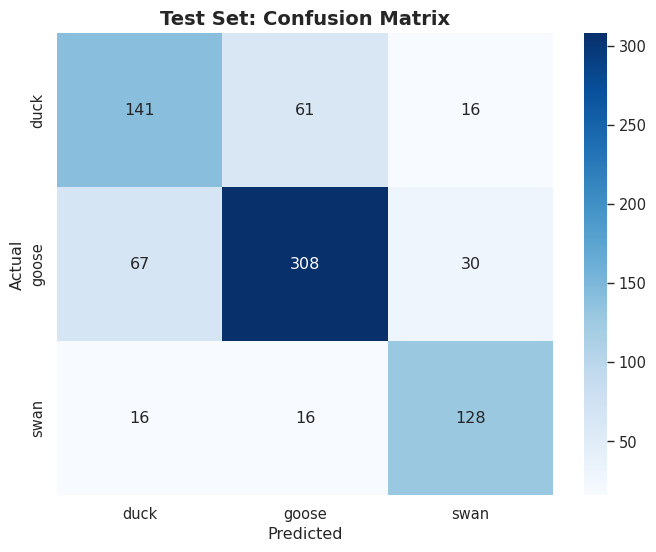

In [40]:
# Plot confusion matrix
plot_confusion_matrix(best_model, test_dataset, class_names, 'Test Set: Confusion Matrix')

##### Figure 1: Test Set Confusion Matrix

Goose is the strongest class (precision 0.80, recall 0.76). The model correctly identified 308/405 geese. This is the model's most reliable category, as expected due to the larger training sample size compared to other classes. 

The main error is that is confuses geese with ducks (67 errors). 

Swan performance is strong, with a precision of 0.74 and a recall of 0.80. The model correctly identified 128/160 swans. Notably, swans are rarely confused with ducks (only 16 errors), this suggests that the model successfully learned unique swan features (such as the long neck or pure white colour) that distinguish them from other classes. 

Duck performance is the primary source of error (precision 0.63, recall 0.65). The model correctly identified 141 ducks, but misclassified 61 ducks as geese and 16 ducks as swans. The visual similarity between ducks and geese is a source of confusion to the model. It is imagined that this is mostly due to juvenile cases, where newborn ducklings and goslings have similar shape profiles. As geese are the majority class, the model is biased towards choosing goose when it is uncertain about a duck image. 

Loaded hypertuning/trial_results_v2/history_logs/trial_3.json


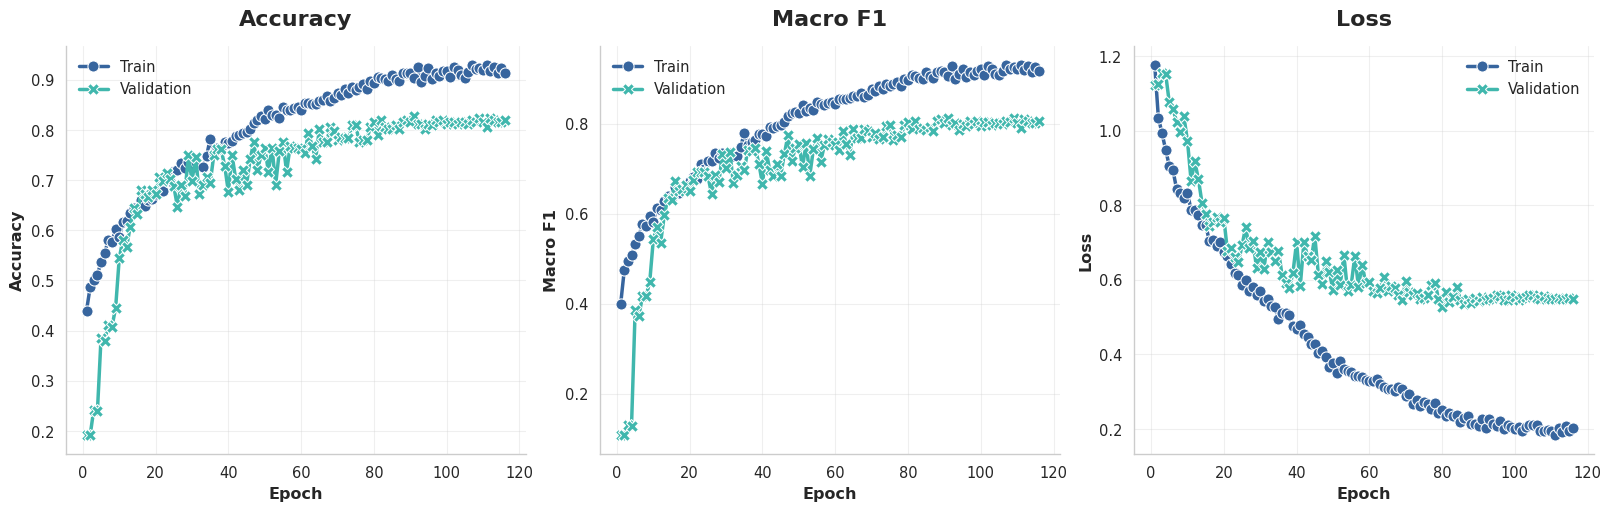

In [41]:
# Plot history from the best hypertuner run
history_path = 'hypertuning/trial_results_v2/history_logs/trial_3.json'
if os.path.exists(history_path):
    with open(history_path, 'r') as f:
        history = json.load(f)
    print(f'Loaded {history_path}')
else: 
    print(f'File not found at: {history_path}')


plot_training_metrics(history)

##### Figure 2 Training and Validation Curves
##### Figure 2a: Accuracy, Figure 2b: Macro F1 Score, Figure 2c: Loss

Figure 2 displays the training and validation curves for Accuracy, Macro F1 and Loss. The figure indicates that the model has learned to generalise well rather than just memorising the training data. 

In figure 2a both the training (dark blue) and validation (teal) curves rise steeply during the first 20 epochs. This indicates the model quickly identified the core features of the dataset. The validation curve follows the training curve closely. While the training accuracy eventually reaches ~92%, the validation accuracy is strong at approximately 82%. 

In figure 2b, the macro F1 score mirrors the accuracy, stabilising around 0.81. Since Macro F1 treats all classes equally, this confirms that the model performs well across all categories, rather than just maximising accuracy by guessing the most common class (Geese). There is a visible gap between training and validation lines (approx 10%), this means the model has enough capacity to learn complex patterns. The validation line remains stable while the training line increases, this suggests that regularisation techniques are working effectively to prevent memorisation. 
 
In figure 2c, the training loss drops consistently, indicating that the model is continuously optimising its weights. The validation loss drops rapidly and then flattens at around 0.55. Importantly, the validation loss remains stable, if it increased this would be a sign of overfitting. The fact that it stays flat indicates that the model has reached its maximum potential with the current data and model architecture. It is assumed that the signinficant gap between training and validation loss is due to the limits of the dataset (small sample size).

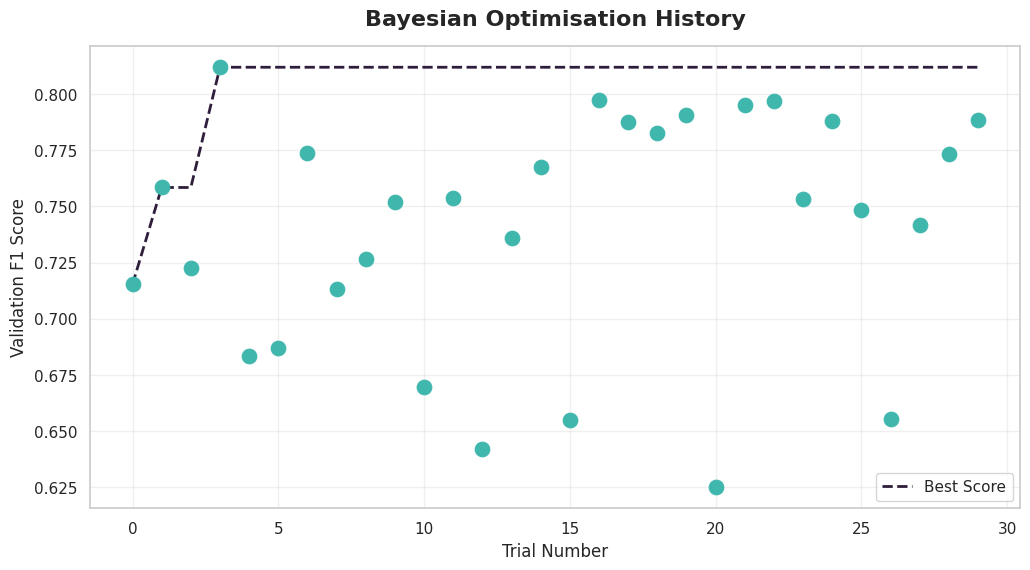

In [42]:
# Plot optimiser history
mako_cols = sns.color_palette("mako", n_colors=6)

palette_dict = {'Train': mako_cols[2], 'Validation': mako_cols[4]}

dot_color = palette_dict['Validation']
line_color = mako_cols[0]

sns.set_theme(style='whitegrid')

plt.figure(figsize=(12, 6))

df['Best So Far'] = df['Score (F1)'].cummax()

plt.plot(
    df['Trial ID'], 
    df['Best So Far'], 
    color=line_color, 
    linestyle='--', 
    linewidth=2, 
    label='Best Score',
    zorder=1
)

sns.scatterplot(
    data=df, 
    x='Trial ID', 
    y='Score (F1)', 
    color=dot_color,       
    s=110, 
    edgecolor=None,
    zorder=2,
    alpha=1.0
)

plt.title('Bayesian Optimisation History', fontsize=16, weight='bold', pad=15)
plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Validation F1 Score', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

##### Figure 3: Bayesian Optimisation History

Figure 3 illustrates the validation macro F1 score against the trial number for the Bayesian optimiser. 

The dashed line displays the best score, which jumps to its maximum value (0.812) very early in the hypertuning operation, at trial 3. This is a characteristic strength of Bayesian optimisation, unlike random search, it quickly identified a promising region of the hyperparameter space. 

Between trial 4 and trial 20, there are several points where the performance drops significantly. This is deliberate exploration on behalf of the optimiser, where suboptimal regions are probed to map the hyperparameter boundaries, confirming that alternative configurations yielded inferior performance. 

The plateau in the best score trajectory indicates that the search converged on the global maximum for the defined search space, validating the decision to terminate the search at 30 trials. 

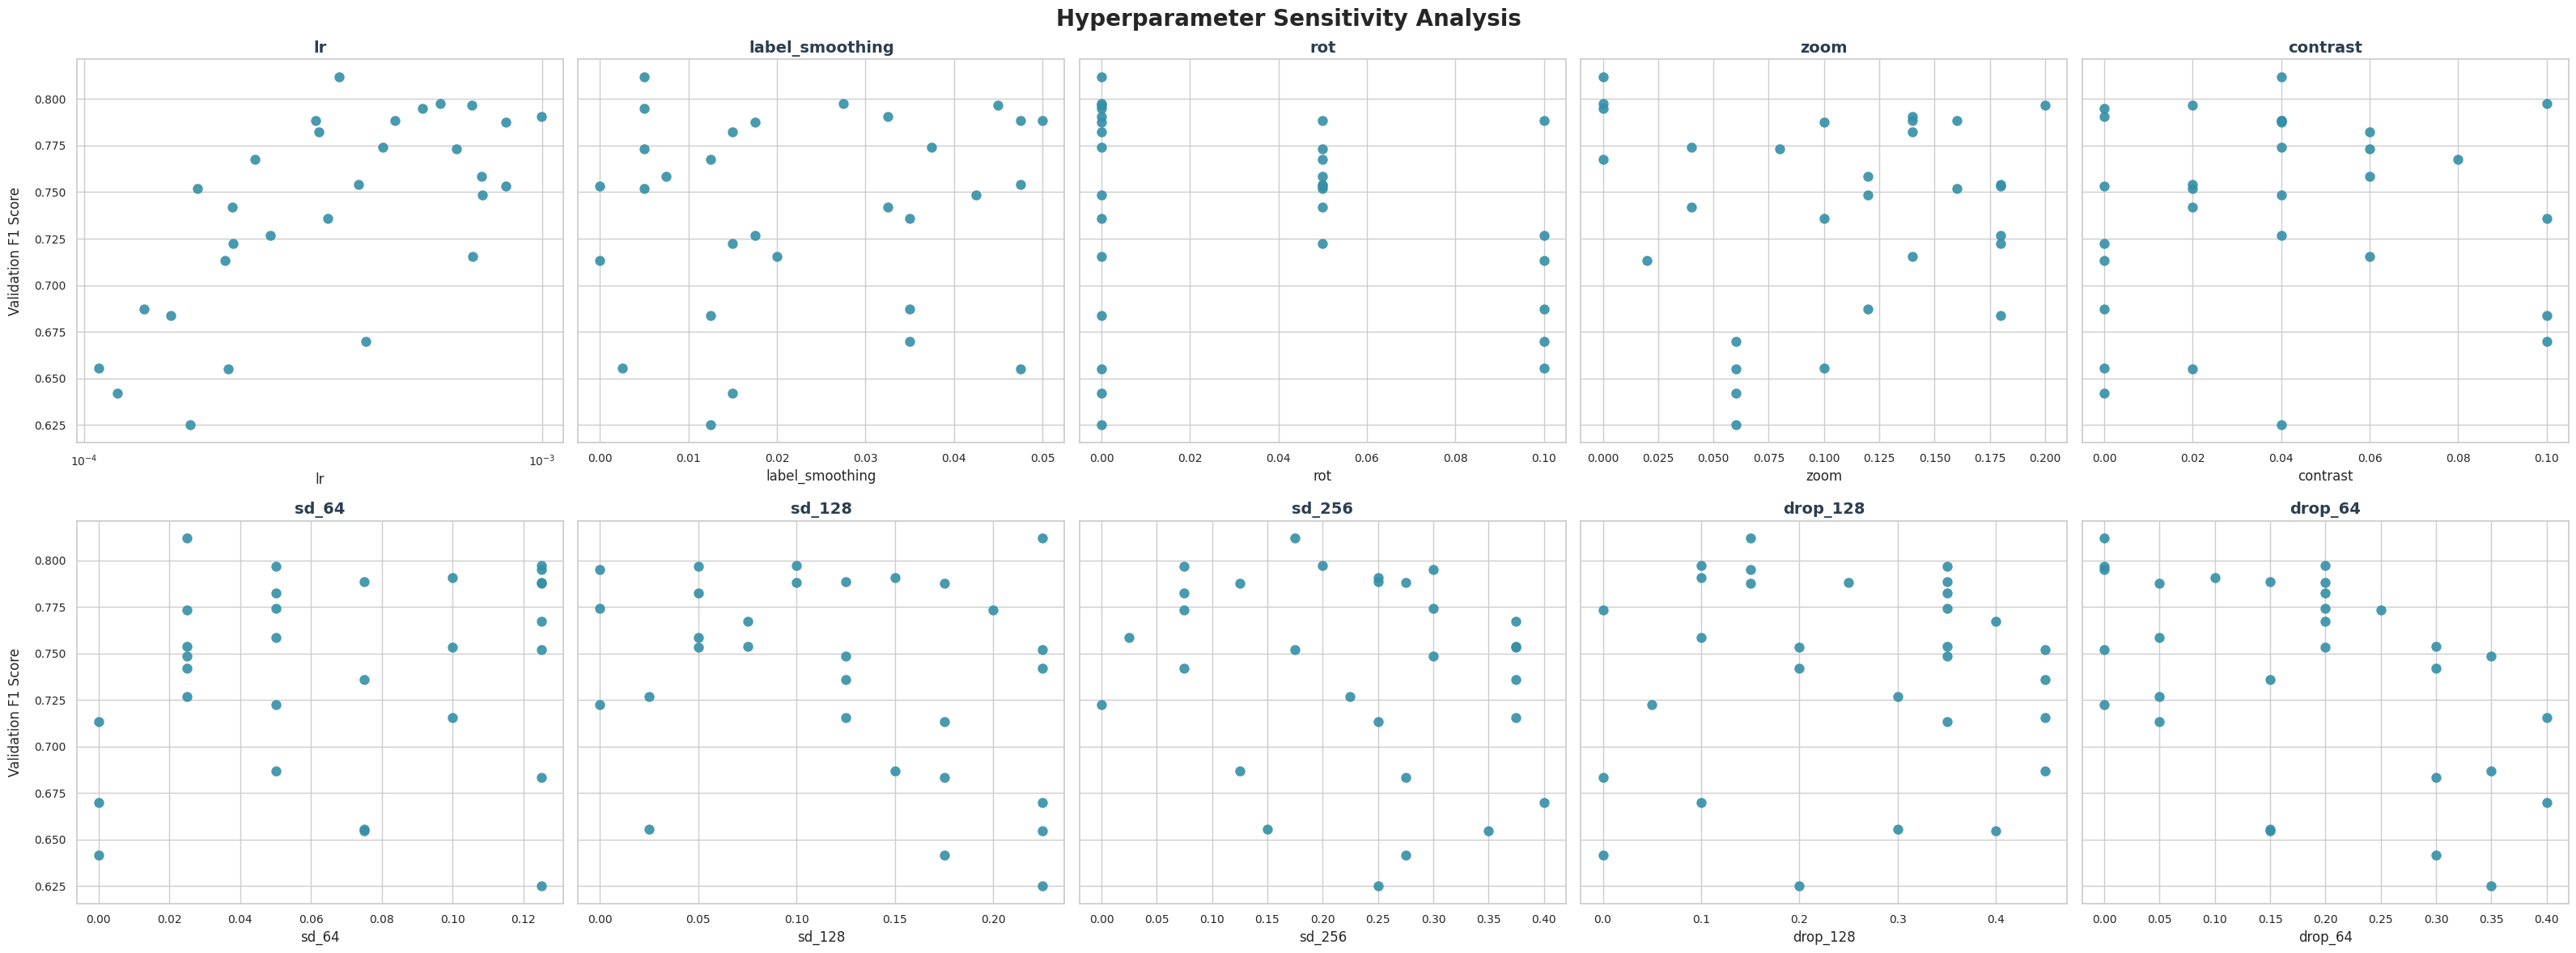

In [43]:
# Plot hyperparameter analysis
mako_colors = sns.color_palette("mako", n_colors=6)
dot_color = mako_colors[3] 

sns.set_theme(style="whitegrid")

params_to_plot = ['lr', 'label_smoothing', 'rot', 'zoom', 'contrast', 'sd_64', 'sd_128', 'sd_256', 'drop_128', 'drop_64'] 

fig, axes = plt.subplots(2, 5, figsize=(32, 12), sharey=True)
axes = axes.flatten()

for i, param in enumerate(params_to_plot):
    if param in df.columns:
        sns.scatterplot(
            ax=axes[i], 
            data=df, 
            x=param, 
            y='Score (F1)', 
            color=dot_color,  
            s=80, 
            linewidth=0,    
            alpha=0.9
        )
        
        if param == 'lr':
            axes[i].set_xscale('log')
            
        axes[i].set_title(f'{param}', fontsize=14, fontweight='bold', color='#2c3e50')
        axes[i].tick_params(axis='both', which='major', labelsize=10)
        
        if i % 5 == 0:
            axes[i].set_ylabel('Validation F1 Score', fontsize=12, labelpad=10)
        else:
            axes[i].set_ylabel('')
    else:
        axes[i].text(0.5, 0.5, 'Not Found', ha='center', color='gray')

plt.suptitle('Hyperparameter Sensitivity Analysis', fontsize=20, y=0.98, weight='bold')
plt.tight_layout()
plt.show()

##### Figure 4: Hyperparameter Sensitivity Analysis

##### Figure 4a: Learning Rate (lr)
These parameters showed a strong positive correlation, rising from lower performance at 10-4 to a peak around 3x10-4 (0.00036). This is the exact point where the model learns fastest without becoming unstable. 

##### Figure 4b: Label Smoothing
A small amount of smoothing was preferred to none, seeing the most performance increase at 0.5%. This suggests that softening hard targets helped the model to handle ambigious cases. 

##### Figure 4c, 4d, 4e: Augmentations - Rotation, Zoom, Contrast
The tuner found optimal values of Rotation: 0.0, Zoom: 0.0 and Contrast: 0.04. 
The lack of strong trends suggest the model is relatively robust to geometric perturbations. The model preferred zero rotation and zoom implying that the dataset already contained sufficient pose variation with the randomflip('horizontal') augmentation. A small amount of contrast augmentation (0.04) was found to be beneficial, however, this only provided a miniscule boost to performance. These findings suggest the model relied more on shape and texture features rather than intensity statistics. 

##### Figure 4f, 4g, 4h, 4i, 4j: Dropout - sd_64, sd_128, sd_256, drop_128, drop_64
 Heavy spatial dropout was applied in the middle (128) block, while the final dense layer dropout was eliminated (0.0). Common practice is to increase dropout deeper in the network, however, the results suggest that the final classifier layer was important in distinguishing differences between classes, while the middle layers needed heavier regularisation.

2026-02-02 13:55:49.156338: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-02 13:55:54.663993: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


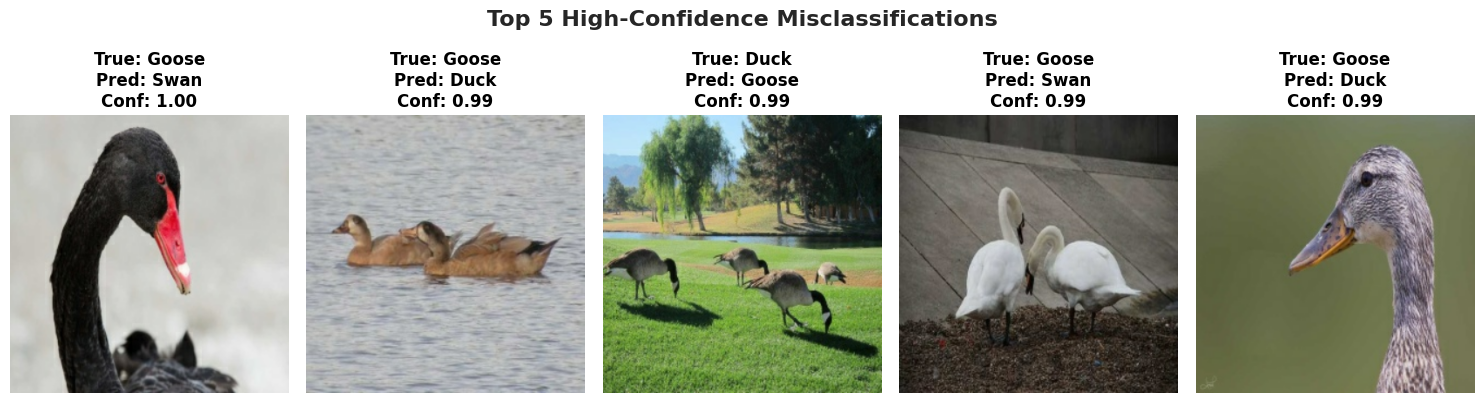

In [44]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Unbatch the test dataset to get individual images
test_images = []
test_labels = []

# Iterate through the test dataset
for img_batch, label_batch in test_dataset:
    # Append batch to list
    test_images.append(img_batch.numpy())
    test_labels.append(label_batch.numpy())

# Stack into a single numpy array
X_test = np.vstack(test_images)
y_test = np.vstack(test_labels)

# Get predictions
y_pred_proba = best_model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred_proba, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Find errors
errors = (y_pred_classes != y_true_classes)
error_indices = np.where(errors)[0]

# Collect error data
error_data = []
for idx in error_indices:
    pred_c = y_pred_classes[idx]
    true_c = y_true_classes[idx]
    confidence = y_pred_proba[idx][pred_c]
    error_data.append((idx, true_c, pred_c, confidence))

# Sort by confidence 
error_data.sort(key=lambda x: x[3], reverse=True)

# Plot the Top 5
class_names = ['Duck', 'Goose', 'Swan']
num_to_plot = min(5, len(error_data))

plt.figure(figsize=(15, 4))

for i in range(num_to_plot):
    idx, true_c, pred_c, conf = error_data[i]
    
    ax = plt.subplot(1, 5, i + 1)
    
    # Display Image 
    img = X_test[idx]
    plt.imshow(img.astype('uint8')) 
    
    plt.title(f"True: {class_names[true_c]}\nPred: {class_names[pred_c]}\nConf: {conf:.2f}", 
              color='black', fontsize=12, fontweight='bold')
    plt.axis("off")

plt.suptitle('Top 5 High-Confidence Misclassifications', fontsize=16, y=1.05, weight='bold')
plt.tight_layout()
plt.show()

##### Figure 5: High-Confidence Misclassifications

Examining high-confidence misclassifications we see the presence of label noise within the test set.

The first image is that of a black swan, with a distinctive red bill. The ground truth label is Goose, however, the model identifies this error and predicts that this is a swan with 100% confidence. This suggests that the model can correctly identify swans based purely on neck and beak shape, without needing colour. 

The third (middle) image in the spread is that of a group of canadian geese, however, the ground truth label is 'Duck'. The model recognised this error and correctly labelled them as 'Goose' with 99% confidence.

Image 4 has a ground truth label of Goose but these are clearly two swans, the model predicts this with 99% accuracy. 

The last image on the right is labelled by the testing set as a goose, however, this is a mallard duck. The model spotted the distinct eyestripe and bill shape, correctly identifying it as a duck despite the goose label. 

This implies that the recorded accuracy of the model is an underestimation of the model's true capacity, as it is being penalised for correctly indentifying human annotation errors. 

## Results and discussion


### Performance of the model
<!-- **TODO:** What do your figures show, and what do the figures indicate about the performance of your model? -->

The CNN model was evaluated on a dataset of 1814 images (1542 training, 272 validation) and a separate test set of 783 images. Given the complexity of bird classification, this sample size is considered relatively small. To contextualise performance, we established two baselines: a random guess (33.3%)and a zero-rule (majority class) baseline of 54.1%, calculated by predicting the majority class (goose, N=981) for every instance.

Against these benchmarks, the model demonstrated strong learning capability, achieving a validation accuracy of 83% and a test accuracy of 74%, surpassing the zero-rule baseline by approximately 20%. This confirms that the network successfully extracted discriminative features.
 
Training dynamics (Figure 2) indicate a stable learning process. The validation loss plateaus and stabilises rather than increasing. This confirms that the regularisation strategy (spatial dropout) successfully prevented destructive overfitting, as the model maintained its generalisation performance even as the training loss continued to decrease. While a gap exists between the training and validation loss, this is characteristic of deep learning on small datasets, the model has sufficient capacity to memorise the limited training examples (1542 images) but lacks the volume of data required to generalise perfectly to unseen variations. 

Class-wise analysis (Figure 1) reflects the class imbalance inherent in the zero-rule baseline. Goose remained the most reliable category (test precision 0.80, recall 0.76), correctly identified in 308 instances. However, swan performance showed high distinctiveness (validation precision 0.89) suggesting the model successfully learned unique features such as neck length or shape. However, swan precision dropped to 0.74 in the testing set, through recall remained relatively robust 0.80. This suggests the model generalises well for retrieving swans but struggles with false positives in noisier test environments.

Bayesian optimisation (figure 3) maximised the validation F1 to 0.81. The sensitivity analysis (figure 4) identified a precise learning rate of 3.6x10-4 and minimal label smoothing (0.5%) as key performance boosts. Interestingly, the optimiser preferred minimal geometric augmentation (rotation/zoom 0.0), implying that minimal augmentations were sufficient for feature extraction on a small dataset.  

### Limitations of this model
<!-- **TODO:** What limits the performance of your model? Discuss here, giving up to three possible explanations and (if useful) referring back to your figures. -->

The discrepancy between validation (83%) and test accuracy (74%) is significantly influenced by poor annotation quality in the test set. Qualitative analysis of high-confidence errors (Figure 5) reveals that the model is frequently penalised for correct predictions. For example, the model predicted swan with 100% confidence for a black swan labeled as goose, and correctly identified mallards and canada geese labeled incorrectly. This confirms that the model has learned robust biological features (e.g. beak structure) that allow it to identify variants correctly (such as the black swan), without having to rely on simpler features such as colour (e.g. not just guessing white feathers = swan). The 9% drop in test performance is likely an artifact of these test set errors rather than a failure of model capacity. 

The duck class is the primary performance bottleneck, achieving the lowest test precision (0.63). The confusion matrix (Figure 1) shows substantial confusion, with 61 ducks misclassified as geese and 67 geese as ducks. This is likely due to visual similarities in juvenile stages (ducklings vs goslings) and breeds with upright postures (e.g. runner ducks) that mimic the geometric profile of geese, causing decision boundary overlap.

With only 1542 training images, the model is constrained by sample efficiency. While it successfully learned core features, such as geometric shapes, neck and beak/bill profiles, the small dataset size limits exposure to diverse poses, occlusions and lighting conditions. The generalisation gap, (validation loss < training loss) indicates that the model has sufficient capacity to learn, but the limited volume of training data prevents it from fully resolving edge cases, leaving it susceptibleto random errors when presented with rare or atypical views in the test set. 


## Conclusion

A Convolutional Neural Network (CNN) was successfully optimised for classification of ducks, geese and swans, achieving a peak validation accuracy of 83% and a test accuracy of 74%. The model significantly outperformed the zero-rule baseline (54.1%), demonstrating that it learned meaningful biological features despite the constraints of a small dataset (N=1814). Through rigorous Bayesian optimisation, distinct hyperparameters were identified that prioritised precise learning rates (3x10-4) and targeted regularisation over heavy geometric augmentation. The model is exceedingly robust to ground-truth label noise. Qualitative analysis confirmed that the network frequently overruled incorrect labels with biologically correct predictions. This suggests that the model has generalised beyond simple pattern matching to learn robust species-specific features, and that future performance gains will depend primarily on dataset cleaning and exposure to a wider variety of images rather than increased architectural complexity. 